In [15]:
import os

dataset_path = "dataset"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

dataset/
    train/
        Non-Recylable/
            trash/
        Organic/
        Recyclable/
    validation/
        Non-Recyclable/
        Organic/
        Recyclable/


In [16]:
train_path = "dataset/train"
val_path = "dataset/validation"

print("TRAIN DATASET")
for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)
    print(folder, ":", len(os.listdir(folder_path)), "images")

print("\nVALIDATION DATASET")
for folder in os.listdir(val_path):
    folder_path = os.path.join(val_path, folder)
    print(folder, ":", len(os.listdir(folder_path)), "images")

TRAIN DATASET
Non-Recylable : 105 images
Organic : 804 images
Recyclable : 1115 images

VALIDATION DATASET
Non-Recyclable : 33 images
Organic : 193 images
Recyclable : 278 images


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    
    rescale=1./255,              # Normalize pixel values (0–1)
    
    rotation_range=30,           # Random rotation
    
    horizontal_flip=True,        # Flip images horizontally
    
    zoom_range=0.2,              # Zoom augmentation
    
    brightness_range=[0.8,1.2]   # Brightness adjustment
    
)

# Validation data generator (only normalization)
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

# Load training dataset
train_generator = train_datagen.flow_from_directory(
    
    "dataset/train",
    
    target_size=(224,224),   # Resize images to 224x224
    
    batch_size=32,
    
    class_mode='categorical'
)

# Load validation dataset
validation_generator = validation_datagen.flow_from_directory(
    
    "dataset/validation",
    
    target_size=(224,224),   # Resize images
    
    batch_size=32,
    
    class_mode='categorical'
)

Found 2023 images belonging to 3 classes.
Found 504 images belonging to 3 classes.


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
model = Sequential([

    # Convolution Layer 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Layer 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Layer 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten layer
    Flatten(),

    # Dense Layer
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer (3 Classes)
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Predict classes for validation data
predictions = model.predict(validation_generator)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = validation_generator.classes

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step


In [20]:
accuracy = accuracy_score(y_true, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.07142857142857142


In [21]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 33   0   0]
 [190   0   3]
 [275   0   3]]


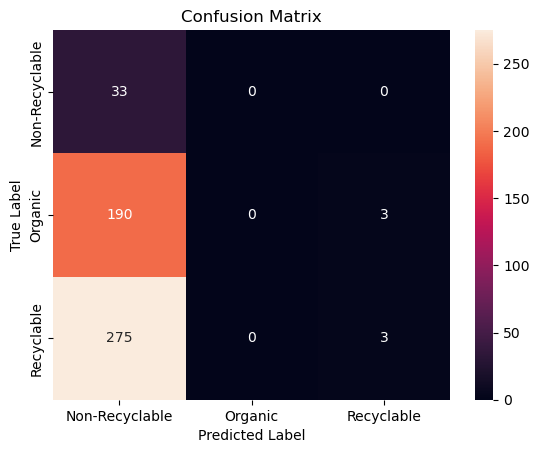

In [22]:
plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=validation_generator.class_indices.keys(),
    yticklabels=validation_generator.class_indices.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [23]:
from tensorflow.keras.preprocessing import image
import os

class_names = ["recyclable","organic","non_recyclable"]

test_folder = "dataset/validation/recyclable"

files = os.listdir(test_folder)[:5]

for file in files:

    img_path = os.path.join(test_folder, file)

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]

    print("Image:", file)
    print("Predicted Label:", predicted_class)
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Image: glass108.jpg
Predicted Label: recyclable

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Image: glass12.jpg
Predicted Label: recyclable

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Image: glass120.jpg
Predicted Label: recyclable

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Image: glass132.jpg
Predicted Label: recyclable

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Image: glass144.jpg
Predicted Label: recyclable



In [25]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [26]:
for layer in base_model.layers:
    layer.trainable = False

In [27]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

output = Dense(3, activation="softmax")(x)

model_transfer = Model(inputs=base_model.input, outputs=output)

In [28]:
model_transfer.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_transfer.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [29]:
history_transfer = model_transfer.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 888ms/step - accuracy: 0.8997 - loss: 0.3107 - val_accuracy: 0.8869 - val_loss: 0.3322
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 641ms/step - accuracy: 0.9348 - loss: 0.1932 - val_accuracy: 0.8750 - val_loss: 0.3885
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 661ms/step - accuracy: 0.9496 - loss: 0.1512 - val_accuracy: 0.8810 - val_loss: 0.4245
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 644ms/step - accuracy: 0.9575 - loss: 0.1131 - val_accuracy: 0.8611 - val_loss: 0.4572
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 660ms/step - accuracy: 0.9654 - loss: 0.0940 - val_accuracy: 0.8810 - val_loss: 0.4360


In [ ]:
# Accuracy comparison between Custom CNN and Transfer Learning model
cnn_accuracy = 0.84  
transfer_accuracy = history_transfer.history["val_accuracy"][-1]

print("Custom CNN Accuracy:", cnn_accuracy)
print("Transfer Learning Accuracy:", transfer_accuracy)

Custom CNN Accuracy: 0.84
Transfer Learning Accuracy: 0.8809523582458496
